# Ethical Issues in AI: Fairness in Recidivism Prediction

Machine learning systems are increasingly used to support decision-making in areas where predictions can have significant consequences for individuals. One such application is recidivism prediction, where machine learning can be used to estimate whether an individual may reoffend within a specified period. Although such systems can support decision-making, differences in model outcomes and prediction errors between demographic groups raise important ethical and fairness concerns.

This project investigates potential unfairness in a machine-learning model using the COMPAS two-year recidivism dataset. A Logistic Regression model is developed to predict two-year recidivism. Race, sex and age are then examined as salient demographic attributes to assess whether the model produces different outcomes or error patterns across groups.

The analysis evaluates group-specific confusion matrices and error measures including False Positive Rate (FPR), False Negative Rate (FNR), False Discovery Rate (FDR) and False Omission Rate (FOR). Additional fairness measures, including Demographic Parity (DP), Disparate Impact (DI), Equal Opportunity (EO) and Equalised Odds, are used to provide different perspectives on fairness. Association-rule mining is also performed to identify patterns associated with the recidivism outcome.

Finally, reweighing is applied as a mitigation approach to examine whether the identified racial disparities can be reduced while maintaining acceptable predictive performance. The baseline and mitigated models are compared using both performance and fairness measures. The study concludes with a critical evaluation of the findings, limitations and recommendations for responsible use of machine-learning systems in consequential decision-making.

Module: M515A — Ethical Issues for AI
Dataset links

Kaggle:
https://www.kaggle.com/datasets/danofer/compass

Original source:
https://github.com/propublica/compas-analysis/blob/master/compas-scores-two-years.csv

Student : Yaseen Khan Mohammed | GH1040702

Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("/content/drive/MyDrive/datasets/compas-scores-two-years.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


Inspect the variables

In [4]:
print(df.columns.tolist())

['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']


The dataset contains variables related to:

demographics
criminal history
COMPAS assessment
current charge
custody
subsequent events
two-year recidivism

Some variables must not be used as predictors because they contain information that would only be known after the assessment.

Check data types and missing values

In [5]:
info = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().mean() * 100).round(2)
})

info.sort_values('missing_%', ascending=False).head(15)

,dtype,missing,missing_%
violent_recid,float64,7214,100.00
vr_charge_degree,object,6395,88.65
vr_offense_date,object,6395,88.65
vr_case_number,object,6395,88.65
vr_charge_desc,object,6395,88.65
c_arrest_date,object,6077,84.24
r_jail_in,object,4898,67.90
r_days_from_arrest,float64,4898,67.90
r_jail_out,object,4898,67.90
r_charge_desc,object,3801,52.69



the data type of each variable
number of missing values
percentage of missing values

We don't want to blindly remove every row containing a missing value because some columns have substantial missingness and may not be needed for our model.

Check duplicates

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


This checks whether the same observation occurs more than once.

Examine the target

In [7]:
target_counts = df['two_year_recid'].value_counts().sort_index()
target_percent = df['two_year_recid'].value_counts(
    normalize=True
).sort_index() * 100

print(pd.DataFrame({
    'count': target_counts,
    'percentage': target_percent.round(2)
}))

                count  percentage
two_year_recid                   
0                3963       54.93
1                3251       45.07


Our target variable is two_year_recid.This means the classes are not extremely imbalanced.

Examine race

In [8]:
race_counts = df['race'].value_counts()

print(race_counts)

race
African-American    3696
Caucasian           2454
Hispanic             637
Other                377
Asian                 32
Native American       18
Name: count, dtype: int64


Race is our primary salient/protected attribute for the fairness investigation.

The dataset contains:

African-American
Caucasian
Hispanic
Other
Asian
Native American

The two smallest groups are very small, so we need to be careful when calculating group-level error rates.

For the main analysis, we'll focus on groups with sufficient observations:

Examine sex and age

In [9]:
print("Sex:")
print(df['sex'].value_counts())

print("\nAge categories:")
print(df['age_cat'].value_counts())

Sex:
sex
Male      5819
Female    1395
Name: count, dtype: int64

Age categories:
age_cat
25 - 45            4109
Greater than 45    1576
Less than 25       1529
Name: count, dtype: int64


We will use:

Race → primary fairness analysis

Sex → secondary fairness analysis

Age category → additional salient-group analysis

This is particularly useful because your previous submission was criticised for not sufficiently analysing different salient groups.

Visualise target by race

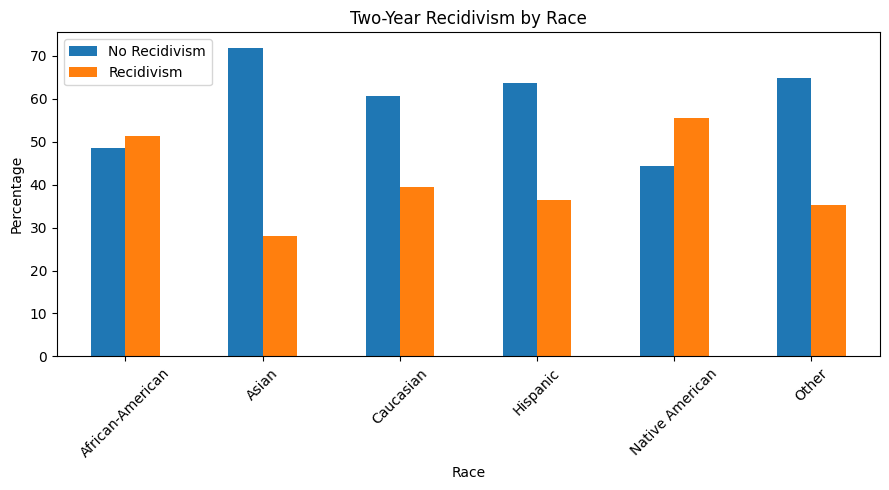

In [10]:
race_recid = pd.crosstab(
    df['race'],
    df['two_year_recid'],
    normalize='index'
) * 100

race_recid.plot(kind='bar', figsize=(9,5))

plt.ylabel('Percentage')
plt.xlabel('Race')
plt.title('Two-Year Recidivism by Race')
plt.xticks(rotation=45)
plt.legend(['No Recidivism', 'Recidivism'])
plt.tight_layout()
plt.show()

This gives us our first indication of whether the target outcome differs between racial groups.

However, this is only an initial descriptive analysis.

A difference in recidivism rates does not by itself prove that the ML model is unfair.

That's why later we'll examine:

confusion matrices
FPR
FNR
FDR
FOR
TPR
TNR
demographic parity
disparate impact
equal opportunity
equalised odds

Basic descriptive statistics

In [11]:
df[['age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'decile_score']].describe()

,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,decile_score
count,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000
mean,34.817993,3.472415,0.067230,0.090934,0.109371,4.509565
std,11.888922,4.882538,0.473972,0.485239,0.501586,2.856396
min,18.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,31.000000,2.000000,0.000000,0.000000,0.000000,4.000000
75%,42.000000,5.000000,0.000000,0.000000,0.000000,7.000000
max,96.000000,38.000000,20.000000,13.000000,17.000000,10.000000


This gives us the distribution of important numerical variables.

For example:

age

previous offences

juvenile offences

COMPAS decile score

This helps us understand the characteristics of the dataset before modelling.

Data preparation and feature selection

Before developing the machine learning model, the dataset was examined to identify variables that are appropriate for predicting two-year recidivism. Although the original dataset contains 53 variables, not all variables are suitable as model inputs. Some columns contain personal identifiers, such as names and identification numbers, which do not provide meaningful predictive information and could introduce privacy concerns. Other variables describe events or outcomes that occur after the initial assessment, such as later case information and subsequent recidivism indicators. Including these variables could cause data leakage, because information that would not have been available when making the original prediction would be used by the model. Therefore, these variables are excluded from the modelling dataset. Variables representing information available around the time of assessment, such as age, previous offence counts and current charge characteristics, are retained as potential predictors. The variables race, sex, and age_cat are retained separately for the fairness analysis. They are not initially used as model predictors so that we can investigate whether differences in model errors occur across demographic groups even when these protected attributes are not directly provided to the model.

Create modelling data

In [12]:
features = [
    'age',
    'priors_count',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'c_charge_degree'
]

target = 'two_year_recid'

model_df = df[features + [target, 'race', 'sex', 'age_cat']].copy()

model_df.head()

,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,two_year_recid,race,sex,age_cat
0,69,0,0,0,0,F,0,Other,Male,Greater than 45
1,34,0,0,0,0,F,1,African-American,Male,25 - 45
2,24,4,0,0,1,F,1,African-American,Male,Less than 25
3,23,1,0,1,0,F,0,African-American,Male,Less than 25
4,43,2,0,0,0,F,0,Other,Male,25 - 45


We create a smaller dataframe containing:

Predictors:

age


prior offences

juvenile offence counts

current charge degree

Target:

two_year_recid

Fairness attributes retained for later analysis:

race

sex

age_cat

The fairness attributes are retained so that after prediction we can calculate the results for each group.

Check missing values in our selected variables

In [13]:
model_df.isnull().sum()

,0
age,0
priors_count,0
juv_fel_count,0
juv_misd_count,0
juv_other_count,0
c_charge_degree,0
two_year_recid,0
race,0
sex,0
age_cat,0


In [14]:
model_df = model_df.dropna(subset=features + [target])

print("Remaining rows:", len(model_df))

Remaining rows: 7214


Unlike the original 53-column dataset, we're now only dealing with variables actually required for our baseline experiment.

Baseline ml model

We now train a baseline Logistic Regression model using the selected variables. This gives us a reference point against which we can later compare the fairness-mitigation method.

We will not include race, sex, or age_cat as predictors in this first model. We retain them in the dataset so that after the model makes predictions, we can examine whether its errors differ between demographic groups.

In [15]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5771
Testing samples: 1443


preprocessing

We have both numerical and categorical variables.

In [16]:
numeric_features = [
    'age',
    'priors_count',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count'
]

categorical_features = ['c_charge_degree']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

We'll standardise numerical variables and one-hot encode the categorical variable.

why ?

Logistic Regression works better when numerical variables are on comparable scales.

One-hot encoding converts categorical values into numerical features without imposing an artificial numerical order.

Train the base model

In [17]:
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

We have two important outputs:

y_pred → predicted class, 0 or 1
y_prob → probability of predicted recidivism

The probabilities will become useful later when discussing thresholds and fairness.

Overall Performance

In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

performance = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    'Value': [accuracy, precision, recall, f1, auc]
}).round(4)

performance



,Metric,Value
0,Accuracy,0.6888
1,Precision,0.7064
2,Recall,0.5292
3,F1,0.6051
4,ROC-AUC,0.7327


What these metrics tell us

Accuracy
Percentage of all predictions that are correct.

Precision
Of the people predicted as recidivating, how many actually recidivated.

Recall / TPR
Of the people who actually recidivated, how many were correctly identified.

F1-score
Balances precision and recall.

ROC-AUC
Measures how well the model separates the two outcome classes across probability thresholds.



Group-Specific Confusion Matrices

An overall confusion matrix describes the model's predictions across the complete test population, but it can hide differences in how the model performs for individual demographic groups. Therefore, separate confusion matrices are constructed for the main racial groups in the test set. Each matrix contains true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN). This allows the distribution of correct and incorrect predictions to be examined separately rather than assuming that the overall model performance applies equally to all groups. In the context of recidivism prediction, a false positive represents an individual who did not recidivate but was predicted to recidivate, while a false negative represents an individual who recidivated but was predicted not to recidivate. Examining these errors by race is important because differences in the frequency of particular error types can indicate that some groups are experiencing different treatment or error rates from the predictive system. These group-specific results are subsequently used to calculate FPR, FNR, FDR and FOR and to investigate disparate mistreatment.





$$ TN=\text{True Negative},\quad FP=\text{False Positive} $$ $$ FN=\text{False Negative},\quad TP=\text{True Positive} $$

In [19]:
test_data = model_df.loc[X_test.index].copy()

test_data['actual'] = y_test
test_data['predicted'] = y_pred

test_data.head()

,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,two_year_recid,race,sex,age_cat,actual,predicted
4688,47,3,0,0,0,F,1,African-American,Male,Greater than 45,1,0
3382,35,1,0,0,0,F,0,African-American,Male,25 - 45,0,0
2460,27,2,0,0,0,F,1,Caucasian,Male,25 - 45,1,0
6974,23,6,0,0,0,F,1,Other,Male,Less than 25,1,1
6187,27,11,0,0,0,F,1,African-American,Male,25 - 45,1,1


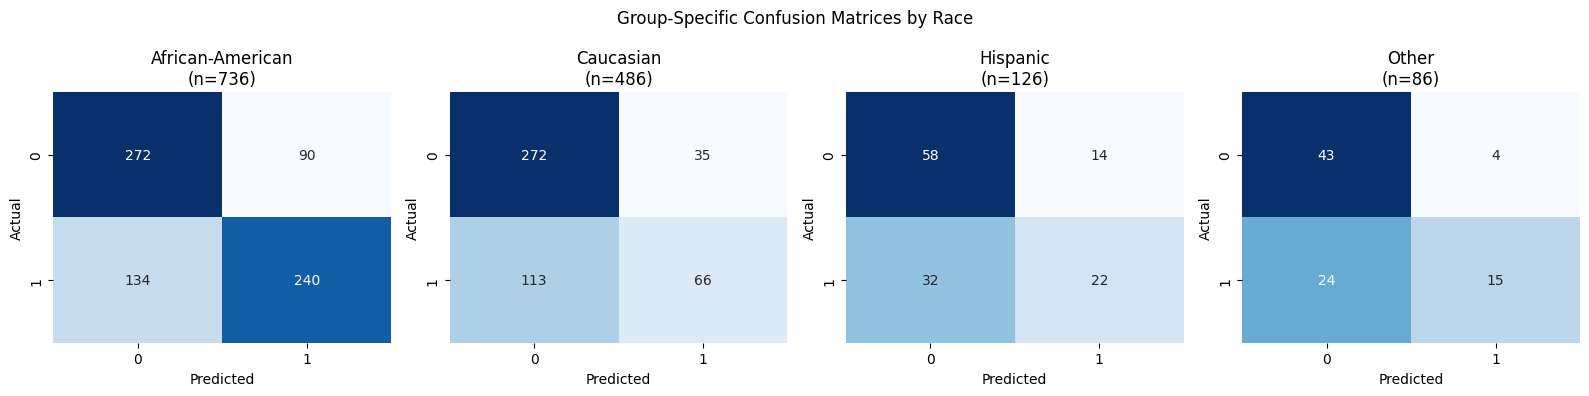

In [20]:
race_groups = ['African-American', 'Caucasian', 'Hispanic', 'Other']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, group in zip(axes, race_groups):
    subset = test_data[test_data['race'] == group]

    cm = confusion_matrix(
        subset['actual'],
        subset['predicted'],
        labels=[0, 1]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax
    )

    ax.set_title(f'{group}\n(n={len(subset)})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Group-Specific Confusion Matrices by Race')
plt.tight_layout()
plt.show()



The overall confusion matrix only tells us how the model performs on everyone combined.

The group-specific matrices allow us to ask:

Does the model make different types of mistakes for different racial groups?

That is exactly what we need for the disparate mistreatment analysis later.

Group-specific confusion matrices: An overall confusion matrix can conceal differences in model errors between demographic groups. Therefore, separate confusion matrices are constructed for the main racial groups. The matrices show true positives, true negatives, false positives and false negatives for each group. False positives represent individuals who did not recidivate but were predicted to recidivate, while false negatives represent individuals who recidivated but were predicted not to recidivate. Comparing these error patterns is important for assessing whether different groups experience different types of prediction errors. Since the groups have different sample sizes, the raw counts are not directly comparable; therefore, they are converted into error rates such as FPR, FNR, FDR and FOR in the following analysis.

Initial interpretation: The confusion matrices show that the model produces different distributions of false-positive and false-negative predictions across the racial groups. The African-American group has 90 false positives and 134 false negatives, whereas the Caucasian group has 35 false positives and 113 false negatives. The Hispanic and Other groups also show different error patterns. However, these values are raw counts and the groups have different sample sizes. For example, the African-American test group contains 736 observations compared with 486 for the Caucasian group and 86 for the Other group. Consequently, the number of errors alone cannot establish that one group is treated less fairly than another. Instead, the error counts must be normalised using group-specific rates.

Then make the important transition:

The next analysis therefore calculates the false-positive rate (FPR), false-negative rate (FNR), false discovery rate (FDR), and false omission rate (FOR) for each racial group. These measures provide a more meaningful comparison of the model's error behaviour across groups.

###Group-Specific Error Rates



$$ FPR=\frac{FP}{FP+TN} $$ $$ FNR=\frac{FN}{FN+TP} $$ $$ FDR=\frac{FP}{FP+TP} $$ $$ FOR=\frac{FN}{FN+TN} $$



In [21]:
def group_metrics(data, group_col, groups):
    results = []

    for group in groups:
        d = data[data[group_col] == group]

        tn, fp, fn, tp = confusion_matrix(
            d['actual'], d['predicted'], labels=[0, 1]
        ).ravel()

        results.append({
            group_col: group,
            'FPR': fp / (fp + tn),
            'FNR': fn / (fn + tp),
            'FDR': fp / (fp + tp),
            'FOR': fn / (fn + tn)
        })

    return pd.DataFrame(results)



race_metrics = group_metrics(
    test_data,
    'race',
    race_groups
)

race_metrics_display = race_metrics.copy()

for col in ['FPR', 'FNR', 'FDR', 'FOR']:
    race_metrics_display[col] = (
        race_metrics_display[col] * 100
    ).round(2)

race_metrics_display


,race,FPR,FNR,FDR,FOR
0,African-American,24.86,35.83,27.27,33.00
1,Caucasian,11.40,63.13,34.65,29.35
2,Hispanic,19.44,59.26,38.89,35.56
3,Other,8.51,61.54,21.05,35.82


In [22]:
sex_groups = test_data['sex'].dropna().unique().tolist()

sex_metrics = group_metrics(
    test_data,
    'sex',
    sex_groups
)

sex_metrics_display = sex_metrics.copy()

for col in ['FPR', 'FNR', 'FDR', 'FOR']:
    sex_metrics_display[col] = (
        sex_metrics_display[col] * 100
    ).round(2)

sex_metrics_display

,sex,FPR,FNR,FDR,FOR
0,Male,20.63,44.32,29.14,33.47
1,Female,9.63,61.54,31.03,27.47


Sex-based analysis: The error rates also differ between male and female individuals. The FPR for males is 20.63%, compared with 9.63% for females. This means that among individuals who did not recidivate, the model incorrectly predicted recidivism more frequently for males. In contrast, the FNR is higher for females (61.54%) than for males (44.32%), indicating that the model more frequently failed to identify female individuals who subsequently recidivated. FDR and FOR also show differences, although their patterns are smaller than those observed for FPR and FNR. These results indicate that the model's error behaviour varies by sex as well as by race.

These differences do not by themselves establish that sex is being used directly to make predictions, since sex was excluded from the model's predictor variables. Instead, they indicate differences in model error rates between demographic groups and therefore provide additional evidence for examining disparate mistreatment.

In [23]:
age_groups = test_data['age_cat'].dropna().unique().tolist()

age_metrics = group_metrics(
    test_data,
    'age_cat',
    age_groups
)

age_metrics_display = age_metrics.copy()

for col in ['FPR', 'FNR', 'FDR', 'FOR']:
    age_metrics_display[col] = (
        age_metrics_display[col] * 100
    ).round(2)
age_metrics_display

,age_cat,FPR,FNR,FDR,FOR
0,Greater than 45,7.37,73.20,38.10,26.10
1,25 - 45,19.06,43.86,28.33,31.76
2,Less than 25,32.31,39.41,28.97,43.23


Age-based analysis: The error rates also vary substantially across age categories. Individuals aged above 45 have the lowest FPR (7.37%) but the highest FNR (73.20%). In contrast, individuals below 25 have the highest FPR (32.31%) and the lowest FNR (39.41%). The 25–45 group falls between these two groups for both measures. Differences are also observed in FDR and FOR, with the below-25 group having the highest FOR (43.23%). These results indicate that the model's error patterns vary considerably across age groups. In particular, the contrasting FPR and FNR values suggest that the model makes different types of prediction errors depending on age category.

Then add:

As with the race and sex analyses, these results do not establish the cause of the observed differences. Age category was not directly used as a model feature; however, the model does use the numerical age variable. Therefore, age is not completely absent from the model, and the observed differences should be interpreted in the context of this modelling decision.

The following analysis converts the confusion-matrix counts into group-specific error rates. FPR measures the proportion of individuals who did not recidivate but were incorrectly predicted to recidivate, while FNR measures the proportion of individuals who recidivated but were incorrectly predicted not to recidivate. FDR represents the proportion of positive predictions that were incorrect, whereas FOR represents the proportion of negative predictions that were incorrect. Comparing these measures across racial groups provides a more meaningful assessment of differences in model errors than comparing raw confusion-matrix counts.

Interpretation of the results

The results show clear differences in error rates between the racial groups. The African-American group has the highest FPR at 24.86%, compared with 11.40% for the Caucasian group and 8.51% for the Other group. This means that, among individuals who did not recidivate, the model incorrectly predicted recidivism more frequently for the African-American group. In contrast, the African-American group has the lowest FNR at 35.83%, while the Caucasian, Hispanic and Other groups have FNR values above 59%. Therefore, the model's errors are not concentrated in a single direction: the African-American group experiences a higher false-positive rate, whereas the other groups experience substantially higher false-negative rates.

Then discuss FDR/FOR:

Differences are also observed in FDR and FOR. The Hispanic group has the highest FDR at 38.89%, meaning that a relatively larger proportion of its positive predictions are false positives. The Other group has the highest FOR at 35.82%, closely followed by the Hispanic group at 35.56%. These differences indicate that the model does not produce identical error patterns across racial groups.

These results provide evidence of different error rates across racial groups, which warrants further investigation of potential disparate mistreatment. However, differences in these metrics alone should not be interpreted as proof that race is directly causing the model's predictions. The baseline model does not use race as a predictor, so the observed differences may arise through other predictive variables and their relationships with the protected groups. Further fairness measures and analysis are therefore required before drawing conclusions about the source of the disparities.

Section 12 — Disparate Treatment

Disparate treatment refers to situations where individuals are treated differently based directly on a protected characteristic such as race or sex. In this study, race was retained in the dataset for fairness auditing but was excluded from the baseline model's predictor variables. The model therefore does not receive race as a direct input when generating recidivism predictions. This reduces the possibility of direct race-based treatment by the classifier. However, excluding a protected attribute does not necessarily eliminate differences in outcomes because other variables may be associated with demographic characteristics and can act as indirect proxies. Therefore, the absence of race from the feature set is treated as evidence about the model design, rather than as proof that disparate treatment is absent.




$$ \Delta_{DT} = P(\hat{Y}=1\mid G_1,Q) - P(\hat{Y}=1\mid G_2,Q) $$

where \(Q\) represents comparable characteristics.



In [24]:
print("Features used by the baseline model:")
for feature in features:
    print("-", feature)

print("\nProtected attributes retained for fairness auditing:")
print("- race")
print("- sex")
print("- age_cat")

Features used by the baseline model:
- age
- priors_count
- juv_fel_count
- juv_misd_count
- juv_other_count
- c_charge_degree

Protected attributes retained for fairness auditing:
- race
- sex
- age_cat


In [25]:
print("Race used as predictor:", 'race' in X.columns)
print("Sex used as predictor:", 'sex' in X.columns)

Race used as predictor: False
Sex used as predictor: False


"Race was not directly used as a model predictor; therefore, the baseline design does not directly condition predictions on race. However, this does not rule out indirect effects or group disparities arising through other variables."

### Disparate Mistreatment
What are we investigating?

We already found that the model has different error rates across racial groups.

Now we want to answer:

Does the model make different types of mistakes for different racial groups?

This is the idea behind disparate mistreatment.

Unlike disparate treatment, which concerns whether protected characteristics are directly used to treat people differently, disparate mistreatment focuses on differences in prediction errors.




$$ \Delta_{FPR}=|FPR_{G_1}-FPR_{G_2}| $$ $$ \Delta_{FNR}=|FNR_{G_1}-FNR_{G_2}| $$ $$ \Delta_{FDR}=|FDR_{G_1}-FDR_{G_2}| $$ $$ \Delta_{FOR}=|FOR_{G_1}-FOR_{G_2}| $$



Disparate mistreatment occurs when a machine learning model produces different error rates for different demographic groups. In this study, disparate mistreatment is assessed by comparing FPR, FNR, FDR and FOR across race, sex and age groups. These measures capture different types of prediction errors and therefore provide a more detailed assessment than overall accuracy. A difference in an error rate indicates that the model's predictions do not affect the groups in the same way for that particular type of error. The analysis does not assume that one group is universally disadvantaged, because a group may have a higher rate for one error type and a lower rate for another.

10.1 Calculate the error-rate gaps

In [26]:
for name, metrics, group_col in [
    ('Race', race_metrics, 'race'),
    ('Sex', sex_metrics, 'sex'),
    ('Age', age_metrics, 'age_cat')
]:
    print(f'\n{name}')

    for metric in ['FPR', 'FNR', 'FDR', 'FOR']:
        gap = metrics[metric].max() - metrics[metric].min()
        print(f'{metric} gap: {gap:.3f}')


Race
FPR gap: 0.164
FNR gap: 0.273
FDR gap: 0.178
FOR gap: 0.065

Sex
FPR gap: 0.110
FNR gap: 0.172
FDR gap: 0.019
FOR gap: 0.060

Age
FPR gap: 0.249
FNR gap: 0.338
FDR gap: 0.098
FOR gap: 0.171


The comparison shows that the baseline model has different error rates across all three demographic attributes examined. For race, the FPR differs by 16.35 percentage points between the highest and lowest groups, while the FNR differs by 27.30 percentage points. For sex, the FPR gap is 11.00 percentage points and the FNR gap is 17.22 percentage points. The largest differences are observed across age categories, where the FPR gap is 24.94 percentage points and the FNR gap is 33.79 percentage points.

These findings provide evidence of unequal error rates consistent with disparate mistreatment in the baseline model. However, the analysis identifies an association between demographic group membership and model errors rather than establishing the cause of these differences. In particular, race and sex were not supplied as model features, while numerical age was included. The observed disparities may therefore reflect relationships between the predictive variables, the underlying data and demographic groups.

The following chart provides a visual comparison of FPR, FNR, FDR and FOR across the demographic groups. The tables remain the primary evidence because race, sex and age contain different numbers of groups. The chart is used to make differences in error rates easier to identify visually.

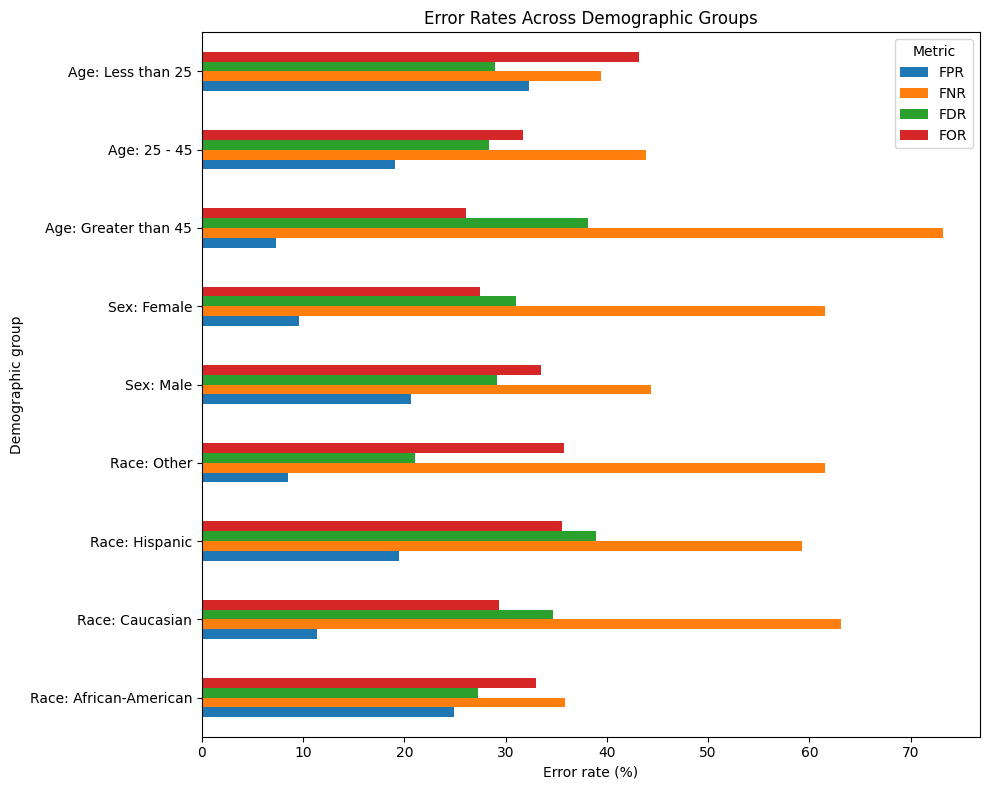

In [27]:
# Combine all groups for one comparison chart

race_plot = race_metrics.copy()
race_plot['Group'] = 'Race: ' + race_plot['race']

sex_plot = sex_metrics.copy()
sex_plot['Group'] = 'Sex: ' + sex_plot['sex']

age_plot = age_metrics.copy()
age_plot['Group'] = 'Age: ' + age_plot['age_cat']

plot_data = pd.concat([
    race_plot[['Group', 'FPR', 'FNR', 'FDR', 'FOR']],
    sex_plot[['Group', 'FPR', 'FNR', 'FDR', 'FOR']],
    age_plot[['Group', 'FPR', 'FNR', 'FDR', 'FOR']]
])

plot_data = plot_data.set_index('Group') * 100

plot_data.plot(
    kind='barh',
    figsize=(10, 8)
)

plt.xlabel('Error rate (%)')
plt.ylabel('Demographic group')
plt.title('Error Rates Across Demographic Groups')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

The visualisation reinforces the differences identified in the metric tables. Age categories show the largest variation in FPR and FNR, followed by racial groups and then sex groups. This is a descriptive comparison of the baseline model's error rates and does not by itself establish that one demographic attribute is inherently more biased than another.

11. DP / DI / EO / Equalised Odds

This section should come after Disparate Mistreatment. Here you move from individual error rates to standard group fairness measures.

11.1 What the measures mean


Demographic Parity (DP) compares the proportion of positive predictions between demographic groups. A value close to zero for the DP difference indicates similar selection rates.

Disparate Impact (DI) compares the positive prediction rate of a reference group with that of another group. A ratio of 1 indicates equal selection rates.

Equal Opportunity (EO) compares the True Positive Rate (TPR) between groups. It therefore focuses on whether actual recidivists are identified at similar rates.

Equalised Odds requires both TPR and False Positive Rate (FPR) to be similar across groups. It therefore considers both types of classification error.

The fairness measures show that positive prediction rates and error-related outcomes differ between demographic groups. Demographic Parity (DP) compares the proportion of individuals receiving positive predictions, while Disparate Impact (DI) expresses the difference as a ratio. Equal Opportunity (EO) compares the True Positive Rate (TPR) between groups, while Equalised Odds provides a stricter comparison by considering both TPR and FPR.

These measures complement the previous FPR, FNR, FDR and FOR analysis. Disparate mistreatment focuses on differences in prediction errors, whereas DP focuses on differences in prediction rates and EO and Equalised Odds examine whether predictive performance is comparable across groups.



Demographic Parity
$$ DP_{diff} = P(\hat{Y}=1\mid G_1) - P(\hat{Y}=1\mid G_2) $$
Disparate Impact
$$ DI= \frac{P(\hat{Y}=1\mid G_1)} {P(\hat{Y}=1\mid G_2)} $$
Equal Opportunity
$$ EO_{diff}=TPR_{G_1}-TPR_{G_2} $$

where

$$ TPR=\frac{TP}{TP+FN} $$
Equalised Odds
$$ EOddsGap= \max \left( |TPR_{G_1}-TPR_{G_2}|, |FPR_{G_1}-FPR_{G_2}| \right) $$



11.2 Calculate the metrics

In [28]:
def fairness_metrics(data, group_col, reference_group):
    results = []

    reference = data[data[group_col] == reference_group]
    tn, fp, fn, tp = confusion_matrix(
        reference['actual'], reference['predicted'], labels=[0, 1]
    ).ravel()

    ref_tpr = tp / (tp + fn)
    ref_fpr = fp / (fp + tn)
    ref_selection = reference['predicted'].mean()

    for group in data[group_col].dropna().unique():
        d = data[data[group_col] == group]

        tn, fp, fn, tp = confusion_matrix(
            d['actual'], d['predicted'], labels=[0, 1]
        ).ravel()

        tpr = tp / (tp + fn)
        fpr = fp / (fp + tn)
        selection = d['predicted'].mean()

        results.append({
            group_col: group,
            'Selection Rate': selection,
            'DP Difference': selection - ref_selection,
            'DI Ratio': selection / ref_selection,
            'EO Difference': tpr - ref_tpr,
            'Equalised Odds Gap': max(
                abs(tpr - ref_tpr),
                abs(fpr - ref_fpr)
            )
        })

    return pd.DataFrame(results)

### 11.1 Race

In [29]:
race_fairness = fairness_metrics(
    test_data,
    'race',
    'Caucasian'
)

race_fairness

,race,Selection Rate,DP Difference,DI Ratio,EO Difference,Equalised Odds Gap
0,African-American,0.448370,0.240551,2.157501,0.272996,0.272996
1,Caucasian,0.207819,0.000000,1.000000,0.000000,0.000000
2,Other,0.220930,0.013111,1.063090,0.015900,0.028900
3,Hispanic,0.285714,0.077895,1.374823,0.038692,0.080438
4,Native American,0.000000,-0.207819,0.000000,-0.368715,0.368715
5,Asian,0.250000,0.042181,1.202970,0.131285,0.131285


In [30]:
race_fairness_display = race_fairness.copy()

for col in ['Selection Rate', 'DP Difference', 'EO Difference',
            'Equalised Odds Gap']:
    race_fairness_display[col] *= 100

race_fairness_display.round(2)

,race,Selection Rate,DP Difference,DI Ratio,EO Difference,Equalised Odds Gap
0,African-American,44.84,24.06,2.16,27.30,27.30
1,Caucasian,20.78,0.00,1.00,0.00,0.00
2,Other,22.09,1.31,1.06,1.59,2.89
3,Hispanic,28.57,7.79,1.37,3.87,8.04
4,Native American,0.00,-20.78,0.00,-36.87,36.87
5,Asian,25.00,4.22,1.20,13.13,13.13


he fairness results show substantial differences in positive prediction rates and error-related outcomes across the racial groups. The Caucasian group is used as the reference group, with a selection rate of 20.78%, so its DP Difference, DI Ratio and EO Difference are 0 and 1.00 respectively.

The African-American group has a selection rate of 44.84%, which is 24.06 percentage points higher than the reference group. Its DI ratio is 2.16, indicating that its positive prediction rate is more than twice that of the Caucasian reference group. Its EO Difference is 27.30 percentage points, showing a substantial difference in TPR compared with the reference group. The Equalised Odds Gap is also 27.30 percentage points.

The Hispanic group has a selection rate of 28.57%, giving a DP Difference of 7.79 percentage points and a DI ratio of 1.37. Its EO Difference is 3.87 percentage points and its Equalised Odds Gap is 8.04 percentage points. The Other group has relatively smaller differences, with a DP Difference of 1.31 percentage points and an Equalised Odds Gap of 2.89 percentage points.

The Native American group has a selection rate of 0%, resulting in a DI ratio of 0.00 and an EO Difference of −36.87 percentage points. However, this group contains very few observations in the dataset, so these results should be interpreted cautiously. Similarly, the Asian group has a small number of observations, meaning its fairness metrics may be unstable.

Overall, the results demonstrate that the baseline model produces different selection rates and true-positive rates across racial groups. These findings complement the FPR, FNR, FDR and FOR analysis and indicate that fairness outcomes depend on which fairness criterion is examined. The small sample sizes of the Native American and Asian groups are an important limitation when interpreting these results.

### 11.2 Sex



In [31]:
sex_fairness = fairness_metrics(
    test_data,
    'sex',
    'Female'
)

sex_fairness_display = sex_fairness.copy()

for col in ['Selection Rate', 'DP Difference', 'EO Difference',
            'Equalised Odds Gap']:
    sex_fairness_display[col] *= 100

sex_fairness_display.round(2)

,sex,Selection Rate,DP Difference,DI Ratio,EO Difference,Equalised Odds Gap
0,Male,37.24,17.31,1.87,17.22,17.22
1,Female,19.93,0.00,1.00,0.00,0.00


The fairness results by sex show differences in positive prediction rates and true-positive rates between male and female individuals. The female group is used as the reference group, with a selection rate of 19.93%. Therefore, its DP Difference and EO Difference are 0, while its DI Ratio is 1.00.

The male group has a selection rate of 37.24%, which is 17.31 percentage points higher than the female reference group. Its DI Ratio is 1.87, meaning that the positive prediction rate for males is 1.87 times the rate for females. The EO Difference is 17.22 percentage points, indicating a difference in the TPR between males and females. The Equalised Odds Gap is also 17.22 percentage points in this result.

These results indicate that the baseline model produces different selection rates and true-positive rates between the two sex groups. This complements the earlier FPR, FNR, FDR and FOR analysis, which also showed differences in model error rates between males and females.

###11.3 Age



In [32]:
age_fairness = fairness_metrics(
    test_data,
    'age_cat',
    '25 - 45'
)

age_fairness_display = age_fairness.copy()

for col in ['Selection Rate', 'DP Difference', 'EO Difference',
            'Equalised Odds Gap']:
    age_fairness_display[col] *= 100

age_fairness_display.round(2)

,age_cat,Selection Rate,DP Difference,DI Ratio,EO Difference,Equalised Odds Gap
0,Greater than 45,13.38,-22.81,0.37,-29.33,29.33
1,25 - 45,36.19,0.00,1.00,0.00,0.00
2,Less than 25,48.33,12.15,1.34,4.45,13.25


Age fairness results — explanation

The fairness results by age category show differences in positive prediction rates and true-positive rates. The 25–45 age group is used as the reference group, with a selection rate of 36.19%. Therefore, its DP Difference and EO Difference are 0 and its DI Ratio is 1.00.

The group aged above 45 has a selection rate of 13.38%, which is 22.81 percentage points lower than the reference group. Its DI Ratio is 0.37, indicating that its positive prediction rate is substantially lower than that of the 25–45 reference group. Its EO Difference is −29.33 percentage points, showing a lower TPR compared with the reference group. The Equalised Odds Gap is 29.33 percentage points.

The group below 25 has a selection rate of 48.33%, which is 12.15 percentage points higher than the reference group. Its DI Ratio is 1.34, while its EO Difference is 4.45 percentage points. Its Equalised Odds Gap is 13.25 percentage points.

Overall, the age groups show substantial differences in selection rates and true-positive rates. These findings are consistent with the differences observed earlier in FPR, FNR, FDR and FOR. In particular, the above-45 group has a substantially lower selection rate and TPR than the 25–45 reference group, while the below-25 group has a higher selection rate. These results demonstrate that the fairness assessment can produce different findings depending on the fairness criterion being examined.

The results show differences in selection rates and TPR across the demographic groups. The DP and DI results therefore indicate that the model does not produce identical positive prediction rates for all groups. The EO results show differences in the rate at which actual recidivists are correctly identified, while the Equalised Odds results indicate differences when both TPR and FPR are considered.

These differences are consistent with the disparities observed in the previous error-rate analysis. However, the metrics measure different aspects of fairness, so no single measure should be interpreted in isolation.

###12. Association Rules

Association rule mining is used to identify combinations of characteristics that are associated with two-year recidivism. This provides an additional perspective on the patterns present in the dataset and complements the fairness analysis of the machine-learning model.

The analysis uses support, confidence and lift. Support measures how frequently a rule occurs in the dataset. Confidence measures how frequently the outcome occurs when the antecedent conditions are present. Lift compares the observed confidence with the overall frequency of the outcome; a lift greater than 1 indicates a positive association.

In [33]:
df[['age', 'priors_count', 'c_charge_degree',
   'race', 'sex', 'two_year_recid']].head()

,age,priors_count,c_charge_degree,race,sex,two_year_recid
0,69,0,F,Other,Male,0
1,34,0,F,African-American,Male,1
2,24,4,F,African-American,Male,1
3,23,1,F,African-American,Male,0
4,43,2,F,Other,Male,0


In [34]:
df[['age', 'priors_count', 'c_charge_degree',
   'race', 'sex', 'two_year_recid']].dtypes

,0
age,int64
priors_count,int64
c_charge_degree,object
race,object
sex,object
two_year_recid,int64


In [35]:
df['c_charge_degree'].value_counts()

,count
c_charge_degree,
F,4666
M,2548


In [36]:
df['two_year_recid'].value_counts()

,count
two_year_recid,
0,3963
1,3251


In [37]:
assoc = df[['age', 'priors_count', 'c_charge_degree',
            'race', 'sex', 'two_year_recid']].dropna().copy()

assoc['age_group'] = pd.cut(
    assoc['age'],
    bins=[0, 25, 45, 100],
    labels=['Under_25', '25_45', 'Over_45']
)

assoc['priors_group'] = pd.cut(
    assoc['priors_count'],
    bins=[-1, 0, 2, 5, np.inf],
    labels=['0', '1_2', '3_5', '6_plus']
)

assoc = assoc.drop(columns=['age', 'priors_count'])

Create the transactions

In [38]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [39]:
transactions = []

for _, row in assoc.iterrows():
    transactions.append([
        f"age={row['age_group']}",
        f"priors={row['priors_group']}",
        f"charge={row['c_charge_degree']}",
        f"race={row['race']}",
        f"sex={row['sex']}",
        f"recid={row['two_year_recid']}"
    ])

te = TransactionEncoder()
encoded = te.fit(transactions).transform(transactions)

transaction_df = pd.DataFrame(
    encoded,
    columns=te.columns_
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

12.4 Find frequent patterns

In [40]:
frequent_itemsets = apriori(
    transaction_df,
    min_support=0.05,
    use_colnames=True
)

frequent_itemsets.sort_values(
    'support',
    ascending=False
).head(10)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,support,itemsets
16,0.806626,(sex=Male)
3,0.646798,(charge=F)
13,0.549348,(recid=0)
0,0.539229,(age=25_45)
59,0.531882,"(sex=Male, charge=F)"
9,0.512337,(race=African-American)
14,0.450652,(recid=1)
29,0.431799,"(sex=Male, age=25_45)"
101,0.425007,"(sex=Male, recid=0)"
93,0.421957,"(race=African-American, sex=Male)"


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


12.5 Generate association rules

In [41]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.55
)

rules = rules[
    rules['consequents'].apply(
        lambda x: 'recid=1' in x
    )
]

rules[['antecedents', 'consequents',
       'support', 'confidence', 'lift']].sort_values(
           'lift',
           ascending=False
).head(10)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift
453,"(race=African-American, sex=Male, priors=6_plu...","(recid=1, charge=F)",0.050873,0.558600,1.765880
239,"(priors=6_plus, age=25_45)","(recid=1, charge=F)",0.078043,0.553045,1.748321
400,"(race=African-American, priors=6_plus, age=25_45)","(recid=1, charge=F)",0.055864,0.552812,1.747584
451,"(age=25_45, race=African-American, priors=6_pl...","(recid=1, sex=Male)",0.050873,0.663653,1.739045
429,"(race=African-American, priors=6_plus, age=25_45)","(recid=1, sex=Male)",0.066953,0.662551,1.736159
441,"(race=African-American, priors=6_plus, charge=F)","(recid=1, sex=Male)",0.071250,0.648172,1.698478
395,"(priors=6_plus, race=African-American)","(recid=1, sex=Male)",0.093568,0.644084,1.687767
415,"(age=25_45, priors=6_plus, charge=F)","(recid=1, sex=Male)",0.068755,0.636714,1.668454
288,"(priors=6_plus, age=25_45)","(recid=1, sex=Male)",0.089409,0.633595,1.660282
447,"(race=African-American, charge=F, age=25_45, p...",(recid=1),0.050873,0.735471,1.632017


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 12.6 Association Rules Results

In [42]:
rules_display = rules[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift']
].copy()

rules_display['antecedents'] = rules_display[
    'antecedents'
].apply(lambda x: ', '.join(sorted(x)))

rules_display['consequents'] = rules_display[
    'consequents'
].apply(lambda x: ', '.join(sorted(x)))

rules_display['support'] = (
    rules_display['support'] * 100
).round(2)

rules_display['confidence'] = (
    rules_display['confidence'] * 100
).round(2)

rules_display = rules_display.sort_values(
    'lift',
    ascending=False
)

rules_display.head(10)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift
453,"age=25_45, priors=6_plus, race=African-America...","charge=F, recid=1",5.09,55.86,1.765880
239,"age=25_45, priors=6_plus","charge=F, recid=1",7.80,55.30,1.748321
400,"age=25_45, priors=6_plus, race=African-American","charge=F, recid=1",5.59,55.28,1.747584
451,"age=25_45, charge=F, priors=6_plus, race=Afric...","recid=1, sex=Male",5.09,66.37,1.739045
429,"age=25_45, priors=6_plus, race=African-American","recid=1, sex=Male",6.70,66.26,1.736159
441,"charge=F, priors=6_plus, race=African-American","recid=1, sex=Male",7.13,64.82,1.698478
395,"priors=6_plus, race=African-American","recid=1, sex=Male",9.36,64.41,1.687767
415,"age=25_45, charge=F, priors=6_plus","recid=1, sex=Male",6.88,63.67,1.668454
288,"age=25_45, priors=6_plus","recid=1, sex=Male",8.94,63.36,1.660282
447,"age=25_45, charge=F, priors=6_plus, race=Afric...",recid=1,5.09,73.55,1.632017


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


12. Association Rules — Results Explanation

Place this immediately below your association-rules table:

The association-rule analysis identifies combinations of characteristics that are associated with two-year recidivism. The strongest rules have lift values above 1, indicating that recidivism occurs more frequently within these combinations than would be expected from the overall recidivism rate.

For example, the rule involving age 25–45, more than six prior offences and African-American race has a support of 5.09%, a confidence of 55.86% and a lift of 1.77. This means that 5.09% of observations satisfy the complete combination, while 55.86% of observations satisfying the antecedent also have the outcome represented in the consequent. The lift of 1.77 indicates a positive association between this combination and the specified outcome.

Another rule involving age 25–45 and more than six prior offences has a support of 7.80%, confidence of 55.30% and lift of 1.75. This shows that the combination occurs relatively frequently and has a positive association with the outcome.

Several of the strongest rules also contain African-American race and male sex, together with a high number of prior offences. For example, the rule containing prior offences above six, African-American race and male sex has a support of 9.36%, confidence of 64.41% and lift of 1.69. These results show that combinations of prior offending history, demographic characteristics and case characteristics are associated with the recidivism outcome in the dataset.

However, association rules identify relationships rather than causal effects. Therefore, these results do not demonstrate that any individual characteristic causes recidivism. They provide additional context for understanding patterns in the data and complement the fairness and error-rate analysis conducted above.

In [43]:
# Generate rules where the consequent is only recid=1

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.55
)

rules = rules[
    rules['consequents'].apply(
        lambda x: x == frozenset({'recid=1'})
    )
].copy()

rules_display = rules[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift']
].copy()

rules_display['antecedents'] = rules_display[
    'antecedents'
].apply(lambda x: ', '.join(sorted(x)))

rules_display['consequents'] = rules_display[
    'consequents'
].apply(lambda x: ', '.join(sorted(x)))

rules_display['support'] = (
    rules_display['support'] * 100
).round(2)

rules_display['confidence'] = (
    rules_display['confidence'] * 100
).round(2)

rules_display = rules_display.sort_values(
    'lift',
    ascending=False
)

rules_display.head(10)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift
447,"age=25_45, charge=F, priors=6_plus, race=Afric...",recid=1,5.09,73.55,1.632017
426,"age=25_45, priors=6_plus, race=African-America...",recid=1,6.70,73.52,1.631327
278,"age=25_45, priors=6_plus, race=African-American",recid=1,7.37,72.98,1.619359
397,"age=25_45, charge=F, priors=6_plus, race=Afric...",recid=1,5.59,72.88,1.617108
237,"age=25_45, charge=F, priors=6_plus",recid=1,7.80,72.27,1.603726
412,"age=25_45, charge=F, priors=6_plus, sex=Male",recid=1,6.88,72.09,1.599751
78,"age=25_45, priors=6_plus",recid=1,10.12,71.71,1.591235
286,"age=25_45, priors=6_plus, sex=Male",recid=1,8.94,71.51,1.586764
438,"charge=F, priors=6_plus, race=African-American...",recid=1,7.13,71.19,1.579738
393,"priors=6_plus, race=African-American, sex=Male",recid=1,9.36,70.98,1.575007


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

The association-rule analysis identifies combinations of characteristics that are associated with two-year recidivism. The reported rules have lift values greater than 1, indicating a positive association between the antecedent conditions and recidivism compared with the overall occurrence of recidivism.

The strongest rule combines age 25–45, charge degree F, more than six prior offences and African-American race. It has a support of 5.09%, confidence of 73.55% and lift of 1.63. This means that 5.09% of observations contain the complete combination, while 73.55% of observations satisfying the antecedent also have a two-year recidivism outcome. The lift of 1.63 indicates that recidivism occurs more frequently within this combination than would be expected from its overall frequency.

Other high-lift rules consistently contain age 25–45 and more than six prior offences. For example, this combination has a support of 10.12%, confidence of 71.71% and lift of 1.59. Adding characteristics such as African-American race, male sex or charge degree F produces further rules with similar confidence and lift values.

These results suggest that prior offending history and age category are recurring characteristics in the strongest association rules, while race and sex also appear in several combinations. However, association rules describe statistical associations rather than causal relationships. Therefore, these patterns should not be interpreted as evidence that race, sex, age or any other individual characteristic causes recidivism.

### 13.1 Mitigation Approach

There are different ways to reduce unfairness in a machine-learning model. Pre-processing methods change the training data before the model is trained, in-processing methods include fairness considerations during model training, and post-processing methods change the model's predictions after training.

For this project, I use **reweighing** as the mitigation method. Reweighing changes the importance given to different training observations by assigning them different weights based on their group and actual outcome. The weighted data is then used to train the model again.

The aim is to reduce the differences observed between the racial groups while keeping the same Logistic Regression model so that the results can be compared with the original model.

###13.3 Applying Reweighing

Reweighing was chosen because it can be applied to the training data without adding race as a prediction feature. This is suitable for this analysis because race was kept separate from the model inputs and was used for the fairness evaluation.

The mitigation focuses on **race** because the baseline results showed differences in FPR, FNR, FDR and FOR between the racial groups, as well as differences in DP, DI, EO and Equalised Odds. Sex and age were also analysed earlier, but race is used as the main attribute for the mitigation so that the effect of one mitigation method can be clearly evaluated.

The same train-test split and Logistic Regression model are kept for the baseline and reweighed models. This makes the before-and-after comparison more consistent.


$$ w(g,y)= \frac{P(g)\times P(y)} {P(g,y)} $$

where:

\(g\) = demographic group
\(y\) = actual outcome
\(w(g,y)\) = weight assigned to that group/outcome combination.



###Create training data

In [44]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="datetime.datetime.utcnow\\(\\) is deprecated"
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [45]:
train_data = model_df.loc[X_train.index].copy()
train_data['race'] = train_data['race'].fillna('Unknown')

##Calculate reweighing weights

In [46]:
# Calculate reweighing weights for race and outcome

n = len(train_data)

group_counts = train_data.groupby(
    ['race', target]
).size()

race_counts = train_data.groupby(
    'race'
).size()

outcome_counts = train_data[target].value_counts()

weights = []

for idx, row in train_data.iterrows():
    race = row['race']
    outcome = row[target]

    weight = (
        race_counts[race] * outcome_counts[outcome]
    ) / (
        n * group_counts[race, outcome]
    )

    weights.append(weight)

train_data['weight'] = weights

train_data[['race', target, 'weight']].head()

,race,two_year_recid,weight
935,Caucasian,0,0.915342
3162,African-American,0,1.134629
5233,Caucasian,0,0.915342
5340,Caucasian,0,0.915342
4523,Hispanic,1,1.293869


### Check the weights

In [47]:
train_data.groupby(
    ['race', target]
)['weight'].agg(['count', 'mean'])

count      mean
race             two_year_recid                 
African-American 0                1433  1.134629
                 1                1527  0.873659
Asian            0                  21  0.732398
                 1                   7  1.802807
Caucasian        0                1181  0.915342
                 1                 787  1.127041
Hispanic         0                 333  0.842917
                 1                 178  1.293869
Native American  0                   5  1.428175
                 1                   8  0.732390
Other            0                 197  0.811400
                 1                  94  1.395258

13.4 Train the mitigated model

In [48]:
mitigated_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

mitigated_model.fit(
    X_train,
    y_train,
    classifier__sample_weight=train_data['weight']
)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'juv_fel_count',
                                                   'juv_misd_count',
                                                   'juv_other_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['c_charge_degree'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [49]:
y_pred_mitigated = mitigated_model.predict(X_test)
y_prob_mitigated = mitigated_model.predict_proba(X_test)[:, 1]

Create the evaluation dataset:

In [50]:
test_data_mitigated = model_df.loc[X_test.index].copy()

test_data_mitigated['actual'] = y_test
test_data_mitigated['predicted'] = y_pred_mitigated

### 13.5 Check overall performance

In [51]:
mitigated_performance = {
    'Accuracy': accuracy_score(y_test, y_pred_mitigated),
    'Precision': precision_score(y_test, y_pred_mitigated),
    'Recall': recall_score(y_test, y_pred_mitigated),
    'F1': f1_score(y_test, y_pred_mitigated),
    'ROC-AUC': roc_auc_score(y_test, y_prob_mitigated)
}

pd.DataFrame(
    mitigated_performance,
    index=['Reweighed Model']
).round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Reweighed Model,0.6881,0.7092,0.5215,0.6011,0.7328


13.6 Recalculate the fairness metrics




In [52]:
race_metrics_mitigated = group_metrics(
    test_data_mitigated,
    'race',
    race_groups
)

race_metrics_mitigated

,race,FPR,FNR,FDR,FOR
0,African-American,0.243094,0.371658,0.272446,0.336562
1,Caucasian,0.114007,0.631285,0.346535,0.293506
2,Hispanic,0.194444,0.592593,0.388889,0.355556
3,Other,0.042553,0.615385,0.117647,0.347826


In [53]:
race_fairness_mitigated = fairness_metrics(
    test_data_mitigated,
    'race',
    'Caucasian'
)

race_fairness_mitigated.round(4)

,race,Selection Rate,DP Difference,DI Ratio,EO Difference,Equalised Odds Gap
0,African-American,0.4389,0.2310,2.1117,0.2596,0.2596
1,Caucasian,0.2078,0.0000,1.0000,0.0000,0.0000
2,Other,0.1977,-0.0101,0.9512,0.0159,0.0715
3,Hispanic,0.2857,0.0779,1.3748,0.0387,0.0804
4,Native American,0.0000,-0.2078,0.0000,-0.3687,0.3687
5,Asian,0.2500,0.0422,1.2030,0.1313,0.1313


13.7 Mitigation Results



Reweighing produced changes in the racial error rates compared with the baseline model. For the African-American group, the FPR decreased from 24.86% to 24.31%, while the FNR increased from 35.83% to 37.17%. The FDR changed only slightly from 27.27% to 27.24%, while the FOR increased from 33.00% to 33.66%. For the Other group, the FPR decreased from 8.51% to 4.26%.

The fairness measures also changed after reweighing. For the African-American group, the DP Difference decreased from 24.06 to 23.10 percentage points and the DI Ratio decreased from 2.16 to 2.11. The EO Difference decreased from 27.30 to 25.96 percentage points. These changes indicate that reweighing reduced some of the measured disparity, although substantial differences remain.

Therefore, reweighing did not eliminate the observed disparities. Instead, it produced a moderate change in the fairness measures while also changing the distribution of prediction errors. This demonstrates the trade-off involved in applying a fairness mitigation technique.

Section 14 — Before vs After



14.1 Overall model performance

In [54]:
mitigated_performance

{'Accuracy': 0.6881496881496881,
 'Precision': 0.7092050209205021,
 'Recall': 0.5215384615384615,
 'F1': 0.601063829787234,
 'ROC-AUC': np.float64(0.7328091958482879)}

In [55]:
baseline_performance = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
}

performance_comparison = pd.DataFrame({
    'Baseline': baseline_performance,
    'Reweighed': mitigated_performance
})

performance_comparison.round(4)

,Baseline,Reweighed
Accuracy,0.6888,0.6881
Precision,0.7064,0.7092
Recall,0.5292,0.5215
F1,0.6051,0.6011
ROC-AUC,0.7327,0.7328


The overall performance results show that reweighing produced only small changes in predictive performance. Accuracy decreased slightly from 0.6888 to 0.6881, while precision increased from 0.7064 to 0.7092. Recall decreased from 0.5292 to 0.5215 and F1 decreased from 0.6051 to 0.6011. ROC-AUC remained almost unchanged, increasing from 0.7327 to 0.7328. Overall, the mitigation therefore resulted in relatively small changes in model performance.

14.2 Fairness comparison

In [56]:
fairness_comparison = race_fairness.copy()

fairness_comparison = fairness_comparison[
    ['race', 'DP Difference', 'DI Ratio',
     'EO Difference', 'Equalised Odds Gap']
].merge(
    race_fairness_mitigated[
        ['race', 'DP Difference', 'DI Ratio',
         'EO Difference', 'Equalised Odds Gap']
    ],
    on='race',
    suffixes=('_Baseline', '_Reweighed')
)

fairness_comparison.round(4)

,race,DP Difference_Baseline,DI Ratio_Baseline,EO Difference_Baseline,Equalised Odds Gap_Baseline,DP Difference_Reweighed,DI Ratio_Reweighed,EO Difference_Reweighed,Equalised Odds Gap_Reweighed
0,African-American,0.2406,2.1575,0.2730,0.2730,0.2310,2.1117,0.2596,0.2596
1,Caucasian,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
2,Other,0.0131,1.0631,0.0159,0.0289,-0.0101,0.9512,0.0159,0.0715
3,Hispanic,0.0779,1.3748,0.0387,0.0804,0.0779,1.3748,0.0387,0.0804
4,Native American,-0.2078,0.0000,-0.3687,0.3687,-0.2078,0.0000,-0.3687,0.3687
5,Asian,0.0422,1.2030,0.1313,0.1313,0.0422,1.2030,0.1313,0.1313


In [57]:
for metric in [
    'DP Difference',
    'DI Ratio',
    'EO Difference',
    'Equalised Odds Gap'
]:
    fairness_comparison[f'{metric} Change'] = (
        fairness_comparison[f'{metric}_Reweighed']
        - fairness_comparison[f'{metric}_Baseline']
    )

fairness_comparison.round(4)

,race,DP Difference_Baseline,DI Ratio_Baseline,EO Difference_Baseline,Equalised Odds Gap_Baseline,DP Difference_Reweighed,DI Ratio_Reweighed,EO Difference_Reweighed,Equalised Odds Gap_Reweighed,DP Difference Change,DI Ratio Change,EO Difference Change,Equalised Odds Gap Change
0,African-American,0.2406,2.1575,0.2730,0.2730,0.2310,2.1117,0.2596,0.2596,-0.0095,-0.0458,-0.0134,-0.0134
1,Caucasian,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,Other,0.0131,1.0631,0.0159,0.0289,-0.0101,0.9512,0.0159,0.0715,-0.0233,-0.1119,0.0000,0.0426
3,Hispanic,0.0779,1.3748,0.0387,0.0804,0.0779,1.3748,0.0387,0.0804,0.0000,0.0000,0.0000,0.0000
4,Native American,-0.2078,0.0000,-0.3687,0.3687,-0.2078,0.0000,-0.3687,0.3687,0.0000,0.0000,0.0000,0.0000
5,Asian,0.0422,1.2030,0.1313,0.1313,0.0422,1.2030,0.1313,0.1313,0.0000,0.0000,0.0000,0.0000


The fairness comparison shows that reweighing reduced several measured disparities, particularly for the African-American group. Its DP Difference decreased from 0.2406 to 0.2310, while its DI Ratio decreased from 2.1575 to 2.1117. Its EO Difference and Equalised Odds Gap also decreased from 0.2730 to 0.2596. These changes indicate movement toward smaller measured differences relative to the Caucasian reference group.

For the Other group, the DP Difference changed from 0.0131 to −0.0101 and the DI Ratio moved from 1.0631 to 0.9512, bringing the selection-rate measures closer to parity. However, its Equalised Odds Gap increased from 0.0289 to 0.0715, showing that improvement in one fairness criterion does not necessarily produce improvement in every criterion.

The Hispanic, Native American and Asian results remained unchanged in the displayed comparison. The very small sample sizes of the Native American and Asian groups mean that their fairness metrics should be interpreted cautiously.

Overall, the results show that reweighing reduced some measured disparities but did not eliminate them or improve every fairness measure for every group. This demonstrates the trade-off between different fairness criteria and the importance of evaluating mitigation using multiple measures rather than relying on a single fairness metric.

15. Critical Evaluation
15.1 Strengths



The analysis has several strengths. First, fairness was evaluated across multiple demographic attributes—race, sex and age—rather than relying on a single protected attribute. Second, group-specific confusion matrices and FPR, FNR, FDR and FOR provide detailed information about different types of prediction errors. Third, DP, DI, EO and Equalised Odds provide complementary fairness perspectives. Finally, reweighing was evaluated using both fairness and predictive-performance measures, allowing its effect to be assessed rather than assuming that mitigation automatically improves fairness.

15.2 Limitations

The model uses a limited set of predictors and Logistic Regression, so its results may differ from those produced by other algorithms or feature sets. Although race and sex were excluded from the model inputs, excluding protected attributes does not guarantee equal outcomes because other variables may be associated with demographic characteristics.

Reweighing reduced some measured racial disparities but did not eliminate them, and some fairness measures remained unchanged or increased. This demonstrates that improving one fairness criterion may not improve all fairness criteria simultaneously. In addition, association rules identify statistical associations rather than causal relationships.

15.3 Fairness–Performance Trade-off


The mitigation produced only small changes in overall predictive performance. Accuracy decreased from 0.6888 to 0.6881 and F1 decreased from 0.6051 to 0.6011, while precision increased from 0.7064 to 0.7092 and ROC-AUC remained almost unchanged at approximately 0.733. At the same time, some racial fairness measures moved closer to parity. This indicates that reweighing can modify fairness outcomes without causing a substantial change in overall model performance, although it did not resolve all measured disparities.

15.4 Overall critical conclusion


Overall, the analysis demonstrates that fairness cannot be assessed using a single metric. The model shows different error patterns across demographic groups, while the mitigation produces mixed effects across fairness criteria. Therefore, fairness assessment should consider multiple error rates, fairness definitions, predictive performance and the characteristics and limitations of the underlying dataset.

###16. Recommendations

16.1 Recommendation based on fairness analysis

The fairness analysis indicates that model evaluation should not rely only on overall accuracy. Group-specific FPR, FNR, FDR and FOR should be monitored alongside DP, DI, EO and Equalised Odds to identify differences in model behaviour between demographic groups.

16.2 Recommendation for model deployment

Before using a recidivism prediction model in a real decision-making environment, fairness should be evaluated separately for relevant demographic groups. Where substantial differences are identified, mitigation techniques such as reweighing should be tested and their effects on both fairness and predictive performance should be documented.

16.3 Recommendation for monitoring

Fairness should be treated as an ongoing monitoring requirement rather than a one-time evaluation. Model performance and group-specific error rates should be periodically reviewed because changes in the underlying population or data distribution may affect both predictive performance and fairness.

16.4 Recommendation regarding small groups

Fairness metrics for groups with very small sample sizes should be interpreted cautiously. The Native American and Asian groups in this dataset contain substantially fewer observations than the larger racial groups. Future analysis should use sufficiently large and representative samples or apply appropriate statistical uncertainty measures before making conclusions about these groups.

16.5 Recommendation regarding model development

Future model development could evaluate alternative algorithms and additional mitigation approaches. Different methods may produce different trade-offs between predictive performance and fairness, so the choice of model should be based on both technical performance and the ethical requirements of the application.

16.6 Business/ethical recommendation

Organisations using risk assessment systems should not treat model predictions as the sole basis for consequential decisions. Predictions should be considered alongside appropriate human review, documented fairness assessments and mechanisms for reviewing potentially incorrect or harmful outcomes.

17. Conclusion

This study investigated potential unfairness in a machine-learning model for predicting two-year recidivism using the COMPAS dataset. The analysis evaluated race, sex and age using group-specific confusion matrices and multiple error measures, including FPR, FNR, FDR and FOR. Additional fairness measures—DP, DI, EO and Equalised Odds—were used to examine differences in selection rates and predictive performance between demographic groups.

The results showed that the baseline model produced different error patterns and fairness outcomes across demographic groups. Association-rule mining also identified combinations of characteristics associated with two-year recidivism, although these relationships should not be interpreted as causal.

Reweighing was applied as a mitigation approach targeting racial disparities. The results showed that some fairness measures moved closer to parity, particularly for the African-American group, while other measures remained unchanged or changed in the opposite direction. Overall predictive performance changed only slightly.

The findings demonstrate that fairness is a multidimensional issue and cannot be evaluated using a single metric. Effective assessment requires consideration of different types of prediction errors, fairness criteria, model performance, data limitations and the potential consequences of automated decision-making. Future implementation should therefore combine fairness monitoring, appropriate mitigation techniques and human oversight.